In [218]:
import numpy as np
import matplotlib.pyplot as plt
import copy

import treecorr

import pyccl as ccl

import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "font.size": 16,          # base font size
    "axes.labelsize": 16,     # x and y labels
    "axes.titlesize": 16,     # title
    "legend.fontsize": 14,    # legend
    "xtick.labelsize": 14,    # x tick labels
    "ytick.labelsize": 14,    # y tick labels
})


import sys
import os
import copy

sys.path.append(os.path.abspath("/home/milan/Desktop/thesis/code")) 

In [219]:
from halo_model.power_spectra.matter_power_baryons import MatterPowerBaryons
from halo_model.power_spectra.matter_power import MatterPower
from halo_model.power_spectra.Pm_computer import Pm_computer
from halo_model.halos.base.profile.profile import CompositeProfile

from halo_model.config.config import Config

In [220]:
from halo_model.halos.base.clump_mass_func.models.giocoli2010_mod import ClumpMassGiocoli2010_mod
from halo_model.halos.base.clump_mass_func.models.giocoli2010 import ClumpMassGiocoli2010
from halo_model.halos.base.clump_mass_func.clump_mass_func import ClumpMassFunc

from halo_model.halos.base.concentration.models.neto2007 import ConcentrationNeto2007
from halo_model.halos.base.concentration.models.scaled_clumps import ConcentrationScaledClumps
from halo_model.halos.base.concentration.models.scaled_distribution import ConcentrationScaledDistribution

from halo_model.halos.base.mass_func.models.tinker2008 import MassFuncTinker2008

from halo_model.halos.base.profile.models.nfw import ProfileNFW
from halo_model.halos.base.profile.models.stellar_truncated_powerlaw import ProfileStellarTruncatedPowerLaw
from halo_model.halos.base.profile.models.pointmass import ProfilePointMass
from halo_model.halos.base.profile.models.gas_cored_powerlaw import ProfileGasCoredPowerLaw


from halo_model.halos.base.bias.models.tinker2010 import BiasTinker2010
from halo_model.halos.base.r_vir.models.SO import R_virSO

from halo_model.halos.base.shmr.models.moster2013 import SHMRMoster2013
from halo_model.halos.base.shmr.models.moster2013_centrals import SHMRMoster2013Centrals
from halo_model.halos.base.shmr.models.Niemiec2022 import SMHRNiemiec2022

In [221]:
#set config & create ccl cosmology object
cfg = Config()

cfg.m_min = 1e3
cfg.M_min = 1e3
cfg.N_M = 64
cfg.N_m = 32

# cfg.theta_ej = 5
# cfg.gamma = 2
cfg.delta = 15
# cfg.mu = 1.4
# cfg.logM_c = 13.2

# Cosmology parameters 

flat = True
H0 = cfg.cosmo.H0
Om0 = cfg.cosmo.Om0
Ob0 = cfg.cosmo.Ob0
sigma8 = cfg.cosmo.sigma8
ns = cfg.cosmo.ns

cosmo = ccl.Cosmology(Omega_c = Om0, Omega_b=Ob0, h=0.01*H0, sigma8=sigma8, n_s=ns)

In [222]:
c_smooth = ConcentrationNeto2007(cfg)
c_clump = ConcentrationScaledClumps(cfg, c_smooth)
c_distribution = ConcentrationScaledDistribution(cfg, c_smooth)
mass_func = MassFuncTinker2008(cfg)

shmr = SHMRMoster2013(cfg, c_smooth)
shmr_central = SHMRMoster2013Centrals(cfg, c_smooth)

smooth_profile_dm = ProfileNFW(c_smooth, R_virSO(cfg))
clump_profile_dm = ProfileNFW(c_clump, R_virSO(cfg))

bias = BiasTinker2010(cfg)

clump_distribution = ProfileNFW(c_distribution, R_virSO(cfg))

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


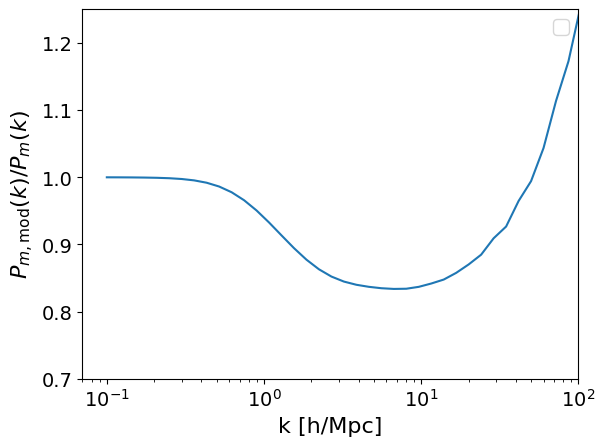

In [223]:
#computing model power spectra
z_grid = np.linspace(cfg.z_max, cfg.z_min, cfg.N_z) # from high redshift to low redshift so scale factor is monotonically increasing
k_grid = np.logspace(np.log10(cfg.k_min), np.log10(cfg.k_max), cfg.N_k)

Nz = len(z_grid)
Nk = len(k_grid)

# compute CDM power spectrum
clump_mass_func = ClumpMassGiocoli2010(cfg)

Pm_dmo = MatterPower(cfg, 
                mass_func=mass_func, 
                smooth_profile=smooth_profile_dm,
                bias=bias,
                clump_mass_func=clump_mass_func, 
                clump_profile=clump_profile_dm, 
                clump_distribution=clump_distribution)
    
Pm_dmo_dict = Pm_computer(Pm_dmo, k_grid)
Pm_dmo_tot = Pm_dmo_dict['P_tot']

# compute baryon power spectrum

gas_profile = ProfileGasCoredPowerLaw(cfg, shmr, c_smooth)
stellar_profile = ProfileStellarTruncatedPowerLaw(cfg, c_smooth)

Pm_baryon = MatterPowerBaryons(cfg, 
                mass_func=mass_func, 
                shmr=shmr,
                shmr_central=shmr_central,
                smooth_profile_dm=smooth_profile_dm,
                stellar_profile=stellar_profile, 
                gas_profile=gas_profile,
                bias=bias,
                clump_mass_func=clump_mass_func, 
                clump_profile_dm=clump_profile_dm, 
                clump_distribution=clump_distribution)

Pm_baryon_dict = Pm_computer(Pm_baryon, k_grid)
Pm_baryon_tot = Pm_baryon_dict['P_tot']


plt.plot(k_grid, Pm_baryon_tot/Pm_dmo_tot)

plt.xscale("log")
plt.ylim(0.7, 1.25)
plt.xlim(7e-2, 1e2)
plt.xlabel('k [h/Mpc]')
plt.ylabel(r'$P_{m, \mathrm{mod}}(k) / P_m(k)$')
plt.legend()
plt.show()

In [224]:

# cfg_2 = copy.deepcopy(cfg)

# cfg_2.S = 2

# gas_profile = ProfileGasCoredPowerLaw(cfg_2, shmr, c_smooth)
# stellar_profile = ProfileStellarTruncatedPowerLaw(cfg_2, c_smooth)

# Pm_baryon_2 = MatterPowerBaryons(cfg_2, 
#                 mass_func=mass_func, 
#                 shmr=shmr,
#                 shmr_central=shmr_central,
#                 smooth_profile_dm=smooth_profile_dm,
#                 stellar_profile=stellar_profile, 
#                 gas_profile=gas_profile,
#                 bias=bias,
#                 clump_mass_func=clump_mass_func, 
#                 clump_profile_dm=clump_profile_dm, 
#                 clump_distribution=clump_distribution)

# Pm_baryon_dict_2 = Pm_computer(Pm_baryon_2, k_grid)
# Pm_baryon_tot_2 = Pm_baryon_dict_2['P_tot']


In [225]:
# load in flamingo data and interpolate:

from scipy.interpolate import interp1d

data = np.genfromtxt(
    "Flamingo_baryonification_reaction.csv",
    delimiter=",",
    skip_header=2,
    filling_values=np.nan,
)

x_f8 = data[:, 0]
y_f8 = data[:, 1]

mask0 = ~np.isnan(data[:, 2]) & ~np.isnan(data[:, 3])
x_f0 = data[mask0, 2]
y_f0 = data[mask0, 3]

f_f8 = interp1d(
    np.log(x_f8), y_f8,
    kind="linear",
    bounds_error=False,
    fill_value="extrapolate"
)

f_f0 = interp1d(
    np.log(x_f0), y_f0,
    kind="linear",
    bounds_error=False,
    fill_value="extrapolate"
)


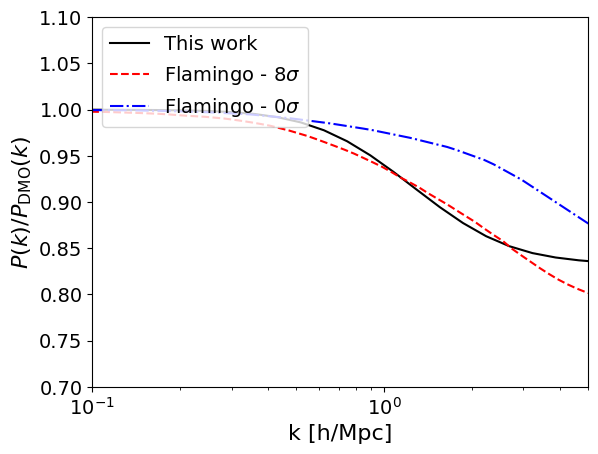

In [226]:
# create ccl Pk2D objects for CDM and WDM power spectra
sys.path.append(os.path.abspath("/home/milan/Desktop/thesis/code/plotting_code/baryonification")) 

a_grid = 1/(1+z_grid)

z_grid_plot = np.linspace(0, 2, 3)
k_grid_plot = np.geomspace(7e-2, 1e2, 100)

f8_flamingo = f_f8(np.log(k_grid_plot))
f0_flamingo  = f_f0(np.log(k_grid_plot))

z=0
plt.plot(k_grid, 
            Pm_baryon_tot / Pm_dmo_tot, 
            label=f'This work',
            color='black',
            linestyle='-',
            )

# plt.plot(k_grid, 
#             Pm_baryon_tot_2 / Pm_dmo_tot, 
#             label=r'Mock HSC-XXL',
#             color='black',
#             linestyle=':',
#             )

plt.plot(k_grid_plot,
            f8_flamingo, 
            label=r'Flamingo - $8\sigma$',
            color='red',
            linestyle='--')

plt.plot(k_grid_plot,
            f0_flamingo, 
            label=r'Flamingo - $0\sigma$',
            color='blue',
            linestyle='-.')

plt.legend(loc="upper left")
plt.ylim(0.7, 1.1)
plt.xlim(1e-1, 5)
plt.xlabel('k [h/Mpc]')
plt.ylabel(r'$P(k) / P_\mathrm{DMO}(k)$')

# plt.title("Power spectrum")
plt.xscale("log")

plt.savefig("baryonification_power_spectrum_comparison.pdf",
            bbox_inches="tight")
plt.show()